In [319]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.preprocessing import  LabelEncoder,StandardScaler
from sklearn.metrics import (accuracy_score,confusion_matrix,classification_report,r2_score)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from joblib import dump, load
import pickle
import warnings
warnings.filterwarnings('ignore')

In [320]:
data=pd.read_csv(r"C:\Users\dell\Downloads\loan_approval_dataset.csv")
data

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...
4264,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


In [321]:
data.head(5)

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [322]:
data.tail(5)

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
4264,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved
4268,1,Graduate,No,9200000,29700000,10,607,17800000,11800000,35700000,12000000,Approved


In [323]:
data.size

51228

In [324]:
data.shape

(4269, 12)

In [325]:
data.columns=data.columns.str.strip()
data.to_csv(r"C:\Users\dell\Downloads\loan_approval_dataset.csv",index=False)
data

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...
4264,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


In [326]:
data.columns

Index(['no_of_dependents', 'education', 'self_employed', 'income_annum',
       'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value',
       'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value',
       'loan_status'],
      dtype='object')

In [327]:
data.isnull().sum()

no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64

In [328]:
data['self_employed'].value_counts()

self_employed
Yes    2150
No     2119
Name: count, dtype: int64

In [329]:
data.duplicated().sum()

np.int64(0)

In [330]:
data.isna().sum()

no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64

In [331]:
data.dtypes

no_of_dependents             int64
education                   object
self_employed               object
income_annum                 int64
loan_amount                  int64
loan_term                    int64
cibil_score                  int64
residential_assets_value     int64
commercial_assets_value      int64
luxury_assets_value          int64
bank_asset_value             int64
loan_status                 object
dtype: object

In [332]:
data.describe()

,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [333]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   no_of_dependents          4269 non-null   int64 
 1   education                 4269 non-null   object
 2   self_employed             4269 non-null   object
 3   income_annum              4269 non-null   int64 
 4   loan_amount               4269 non-null   int64 
 5   loan_term                 4269 non-null   int64 
 6   cibil_score               4269 non-null   int64 
 7   residential_assets_value  4269 non-null   int64 
 8   commercial_assets_value   4269 non-null   int64 
 9   luxury_assets_value       4269 non-null   int64 
 10  bank_asset_value          4269 non-null   int64 
 11  loan_status               4269 non-null   object
dtypes: int64(9), object(3)
memory usage: 400.3+ KB


<h2>Visualising Using Matplotlib</h2>

<Axes: xlabel='loan_status', ylabel='count'>

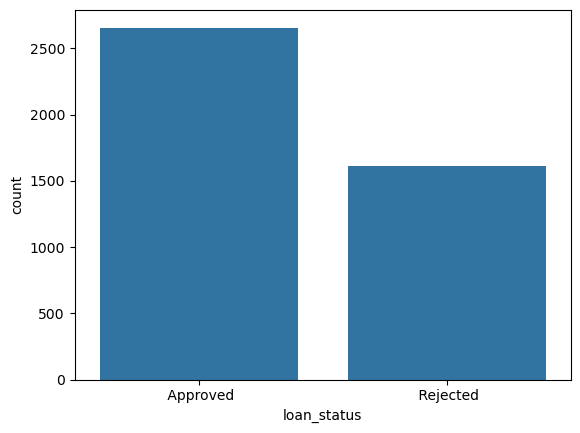

In [334]:
sns.countplot(x='loan_status',data=data)

<Axes: xlabel='self_employed', ylabel='income_annum'>

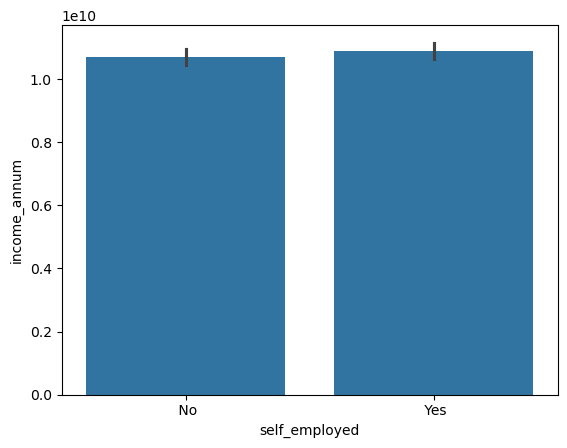

In [335]:
sns.barplot(x=data['self_employed'],y=data['income_annum'],data=data,estimator=sum)

<Axes: xlabel='self_employed', ylabel='count'>

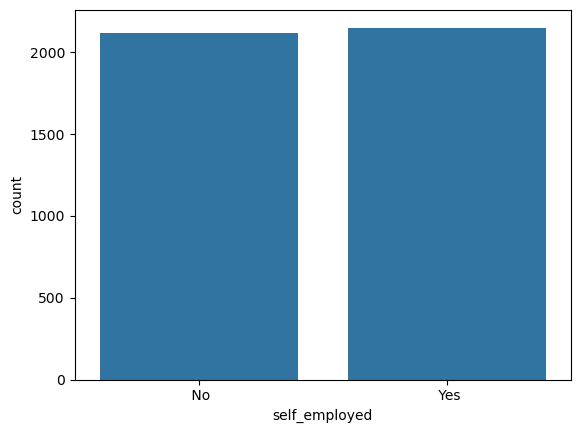

In [336]:
sns.countplot(x=data['self_employed'],data=data)

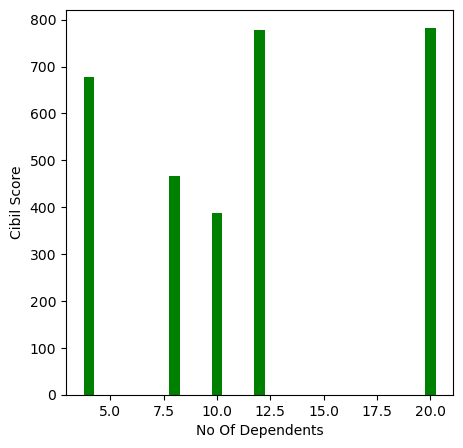

In [337]:
grouped_cnt=data.groupby('no_of_dependents')['loan_amount'].max()
grouped_cnt
x=data['loan_term'].head(10)
y=data['cibil_score'].head(10)
plt.figure(figsize=(5,5))
plt.bar(x,y,color="green",width=0.5)
plt.xlabel("No Of Dependents")
plt.ylabel("Cibil Score")
plt.show()

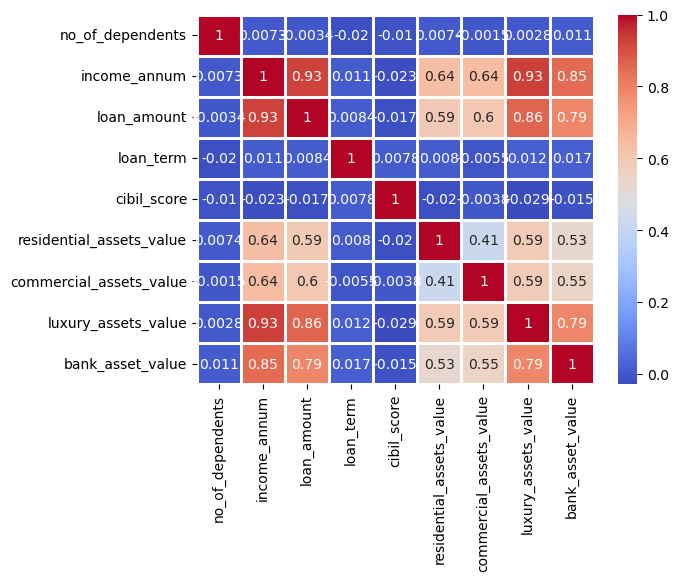

In [338]:
dt=data.corr(numeric_only=True)
sns.heatmap(dt,annot=True,cmap='coolwarm',linewidth=1)
plt.show()

In [339]:
data.head(2)

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected


<h3>Converting Categorical Values Into Numerical Values</h3>

In [340]:
edu=LabelEncoder()
self_emp=LabelEncoder()
data['education']=edu.fit_transform(data['education'])
data['self_employed']=self_emp.fit_transform(data['self_employed'])
data

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,0,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,0,1,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,0,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,0,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,1,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...
4264,5,0,1,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,0,1,1,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,2,1,0,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,1,1,0,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


<h2>Selecting Target Value</h2>

In [341]:
x=data.drop('loan_status',axis=1)
y=data.loan_status
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)
X_test

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
1703,5,0,0,5400000,19700000,20,423,6500000,10000000,15700000,7300000
1173,2,0,0,5900000,14000000,8,599,4700000,9500000,17800000,6700000
308,3,0,0,9600000,19900000,14,452,4200000,16200000,28500000,6600000
1322,2,0,0,6200000,23400000,8,605,10000000,10800000,21800000,9200000
3271,3,1,1,5800000,14100000,12,738,11700000,4400000,15400000,8400000
...,...,...,...,...,...,...,...,...,...,...,...
3663,5,0,1,4500000,17100000,2,639,10600000,7500000,12000000,6500000
1509,3,0,0,1000000,2800000,4,757,2500000,100000,3800000,900000
604,2,0,1,4300000,16000000,14,623,9800000,6700000,17000000,4500000
3597,5,1,1,4000000,15500000,12,517,0,600000,12100000,3500000


<h2>Model Fitting</h2>

In [342]:
scaler=StandardScaler()
model1=LogisticRegression()
xtrain=scaler.fit_transform(X_train)
xtest=scaler.transform(X_test)
fitmodel1=model1.fit(xtrain,y_train)
logis_pred=model1.predict(xtest)

logis_train_score=model1.score(xtrain,y_train)
logis_test_score=model1.score(xtest,y_test)

logis_class_rep=classification_report(y_test,logis_pred,output_dict=True)
logis_cm=confusion_matrix(y_test,logis_pred)
logis_test_acc=accuracy_score(y_test,logis_pred)




<h2>Logistic Regression Result</h2>

In [343]:
print("Classification Report:",logis_class_rep)
print("Confusion Matrix:",logis_cm)

print("Accuracy:",logis_test_acc)
print("Training Score:",logis_train_score)
print("Test Score:",logis_test_score)


Classification Report: {' Approved': {'precision': 0.922514619883041, 'recall': 0.9306784660766961, 'f1-score': 0.9265785609397944, 'support': 678.0}, ' Rejected': {'precision': 0.8776041666666666, 'recall': 0.8641025641025641, 'f1-score': 0.8708010335917312, 'support': 390.0}, 'accuracy': 0.9063670411985019, 'macro avg': {'precision': 0.9000593932748537, 'recall': 0.8973905150896302, 'f1-score': 0.8986897972657628, 'support': 1068.0}, 'weighted avg': {'precision': 0.906114735281556, 'recall': 0.9063670411985019, 'f1-score': 0.906210362750895, 'support': 1068.0}}
Confusion Matrix: [[631  47]
 [ 53 337]]
Accuracy: 0.9063670411985019
Training Score: 0.921899406435489
Test Score: 0.9063670411985019


<h2>Decision Tree</h2>

In [344]:
model2=DecisionTreeClassifier()
fitmodel2=model2.fit(xtrain,y_train)
decis_pred=model2.predict(xtest)

decis_train_score=model2.score(xtrain,y_train)
decis_test_score=model2.score(xtest,y_test)

decis_class_rep=classification_report(y_test,decis_pred,output_dict=True)
decis_cm=confusion_matrix(y_test,decis_pred)
decis_test_acc=accuracy_score(y_test,decis_pred)

<h2>Decision Tree Result</h2>

In [345]:
print("Classification Report:",decis_class_rep)
print("Confusion Matrix:",decis_cm)

print("Accuracy:",decis_test_acc)
print("Training Score:",decis_train_score)
print("Test Score:",decis_test_score)

Classification Report: {' Approved': {'precision': 0.9838235294117647, 'recall': 0.9867256637168141, 'f1-score': 0.9852724594992637, 'support': 678.0}, ' Rejected': {'precision': 0.9768041237113402, 'recall': 0.9717948717948718, 'f1-score': 0.974293059125964, 'support': 390.0}, 'accuracy': 0.9812734082397003, 'macro avg': {'precision': 0.9803138265615524, 'recall': 0.979260267755843, 'f1-score': 0.9797827593126138, 'support': 1068.0}, 'weighted avg': {'precision': 0.9812602632852051, 'recall': 0.9812734082397003, 'f1-score': 0.9812631279022721, 'support': 1068.0}}
Confusion Matrix: [[669   9]
 [ 11 379]]
Accuracy: 0.9812734082397003
Training Score: 1.0
Test Score: 0.9812734082397003


<h3>Random Forest</h3>

In [346]:
model3=RandomForestClassifier(n_estimators=30,random_state=1)
model3.fit(xtrain,y_train)
rand_pred=model3.predict(xtest)

rand_train_score=model3.score(xtrain,y_train)
rand_test_score=model3.score(xtest,y_test)

rand_class_rep=classification_report(y_test,rand_pred,output_dict=True)
rand_cm=confusion_matrix(y_test,rand_pred)
rand_test_acc=accuracy_score(y_test,rand_pred)

<h5>Random Forest Result</h5>

In [347]:
print("Classification Report:",rand_class_rep)
print("Confusion Matrix:",rand_cm)

print("Accuracy:",rand_test_acc)
print("Training Score:",rand_train_score)
print("Test Score:",rand_test_score)

Classification Report: {' Approved': {'precision': 0.9809663250366032, 'recall': 0.9882005899705014, 'f1-score': 0.9845701689933872, 'support': 678.0}, ' Rejected': {'precision': 0.9792207792207792, 'recall': 0.9666666666666667, 'f1-score': 0.9729032258064516, 'support': 390.0}, 'accuracy': 0.9803370786516854, 'macro avg': {'precision': 0.9800935521286912, 'recall': 0.977433628318584, 'f1-score': 0.9787366973999194, 'support': 1068.0}, 'weighted avg': {'precision': 0.9803289066207125, 'recall': 0.9803370786516854, 'f1-score': 0.9803097683914165, 'support': 1068.0}}
Confusion Matrix: [[670   8]
 [ 13 377]]
Accuracy: 0.9803370786516854
Training Score: 1.0
Test Score: 0.9803370786516854


<h3>K-Neighbour</h3>

In [348]:
model4=KNeighborsClassifier(n_neighbors=20)
model4.fit(xtrain,y_train)
kneig_pred=model4.predict(xtest)

kneig_train_score=model4.score(xtrain,y_train)
kneig_test_score=model4.score(xtest,y_test)

kneig_class_rep=classification_report(y_test,kneig_pred,output_dict=True)
kneig_cm=confusion_matrix(y_test,kneig_pred)
kneig_test_acc=accuracy_score(y_test,kneig_pred)

<h5>K-Neighbour Report</h5>

In [349]:
print("Classification Report:",kneig_class_rep)
print("Confusion Matrix:",kneig_cm)

print("Accuracy:",kneig_test_acc)
print("Training Score:",kneig_train_score)
print("Test Score:",kneig_test_score)

Classification Report: {' Approved': {'precision': 0.9144927536231884, 'recall': 0.9306784660766961, 'f1-score': 0.922514619883041, 'support': 678.0}, ' Rejected': {'precision': 0.8756613756613757, 'recall': 0.8487179487179487, 'f1-score': 0.8619791666666666, 'support': 390.0}, 'accuracy': 0.900749063670412, 'macro avg': {'precision': 0.8950770646422821, 'recall': 0.8896982073973224, 'f1-score': 0.8922468932748537, 'support': 1068.0}, 'weighted avg': {'precision': 0.9003127560528634, 'recall': 0.900749063670412, 'f1-score': 0.9004089768545898, 'support': 1068.0}}
Confusion Matrix: [[631  47]
 [ 59 331]]
Accuracy: 0.900749063670412
Training Score: 0.9228366135582631
Test Score: 0.900749063670412


<h1>Adab Booster</h1>

In [350]:
model5=AdaBoostClassifier(n_estimators=50,random_state=1)
model5.fit(xtrain,y_train)
adab_pred=model5.predict(xtest)

adab_train_score=model5.score(xtrain,y_train)
adab_test_score=model5.score(xtest,y_test)

adab_class_rep=classification_report(y_test,adab_pred,output_dict=True)
adab_cm=confusion_matrix(y_test,adab_pred)
adab_test_acc=accuracy_score(y_test,adab_pred)

<h5>Adab Booster Report</h5>

In [351]:
print("Classification Report:",adab_class_rep)
print("Confusion Matrix:",adab_cm)

print("Accuracy:",adab_test_acc)
print("Training Score:",adab_train_score)
print("Test Score:",adab_test_score)

Classification Report: {' Approved': {'precision': 0.9762258543833581, 'recall': 0.9690265486725663, 'f1-score': 0.9726128793486306, 'support': 678.0}, ' Rejected': {'precision': 0.9468354430379747, 'recall': 0.958974358974359, 'f1-score': 0.9528662420382166, 'support': 390.0}, 'accuracy': 0.9653558052434457, 'macro avg': {'precision': 0.9615306487106664, 'recall': 0.9640004538234627, 'f1-score': 0.9627395606934236, 'support': 1068.0}, 'weighted avg': {'precision': 0.9654934008021787, 'recall': 0.9653558052434457, 'f1-score': 0.9654020286453894, 'support': 1068.0}}
Confusion Matrix: [[657  21]
 [ 16 374]]
Accuracy: 0.9653558052434457
Training Score: 0.9675101530771634
Test Score: 0.9653558052434457


<h1>Gradient Boost</h1>

In [352]:
model6=GradientBoostingClassifier(n_estimators=50,random_state=1)
model6.fit(xtrain,y_train)
grad_pred=model6.predict(xtest)

grad_train_score=model6.score(xtrain,y_train)
grad_test_score=model6.score(xtest,y_test)

grad_class_rep=classification_report(y_test,grad_pred,output_dict=True)
grad_cm=confusion_matrix(y_test,grad_pred)
grad_test_acc=accuracy_score(y_test,grad_pred)

<h5>Gradient Boost Report</h5>

In [353]:
print("Classification Report:",grad_class_rep)
print("Confusion Matrix:",grad_cm)

print("Accuracy:",grad_test_acc)
print("Training Score:",grad_train_score)
print("Test Score:",grad_test_score)

Classification Report: {' Approved': {'precision': 0.9711399711399712, 'recall': 0.9926253687315634, 'f1-score': 0.9817651349380014, 'support': 678.0}, ' Rejected': {'precision': 0.9866666666666667, 'recall': 0.9487179487179487, 'f1-score': 0.9673202614379085, 'support': 390.0}, 'accuracy': 0.9765917602996255, 'macro avg': {'precision': 0.9789033189033189, 'recall': 0.970671658724756, 'f1-score': 0.974542698187955, 'support': 1068.0}, 'weighted avg': {'precision': 0.9768098318660118, 'recall': 0.9765917602996255, 'f1-score': 0.976490321581226, 'support': 1068.0}}
Confusion Matrix: [[673   5]
 [ 20 370]]
Accuracy: 0.9765917602996255
Training Score: 0.9862542955326461
Test Score: 0.9765917602996255


<h1>Representing Models Training and Testing Score Graphically </h1>

In [354]:
score=pd.DataFrame({'Model':['LogisticClassification','DecisionTreeClassifier','RandomForestClassifier',
                           'KNeighborClassifier','AdaBoostClassifier','GradientBoostClassifier'],
                    'Report_Acc':[logis_class_rep['accuracy'],decis_class_rep['accuracy'],rand_class_rep['accuracy'],kneig_class_rep['accuracy']
                                    ,adab_class_rep['accuracy'],grad_class_rep['accuracy']],
                    'Training_Score': [
        logis_train_score,
        decis_train_score,
        rand_train_score,
        kneig_train_score,
        adab_train_score,
        grad_train_score
    ],

    'Test_Score': [
        logis_test_score,
        decis_test_score,
        rand_test_score,
        kneig_test_score,
        adab_test_score,
        grad_test_score
    ],
                    'Accuracy':
                     [
        logis_test_acc,
        decis_test_acc,
        rand_test_acc,
        kneig_test_acc,
        adab_test_acc,
        grad_test_acc
    ],
                    
                   })
score.sort_values(by="Accuracy",ascending=False)

,Model,Report_Acc,Training_Score,Test_Score,Accuracy
1,DecisionTreeClassifier,0.981273,1.000000,0.981273,0.981273
2,RandomForestClassifier,0.980337,1.000000,0.980337,0.980337
5,GradientBoostClassifier,0.976592,0.986254,0.976592,0.976592
4,AdaBoostClassifier,0.965356,0.967510,0.965356,0.965356
0,LogisticClassification,0.906367,0.921899,0.906367,0.906367
3,KNeighborClassifier,0.900749,0.922837,0.900749,0.900749


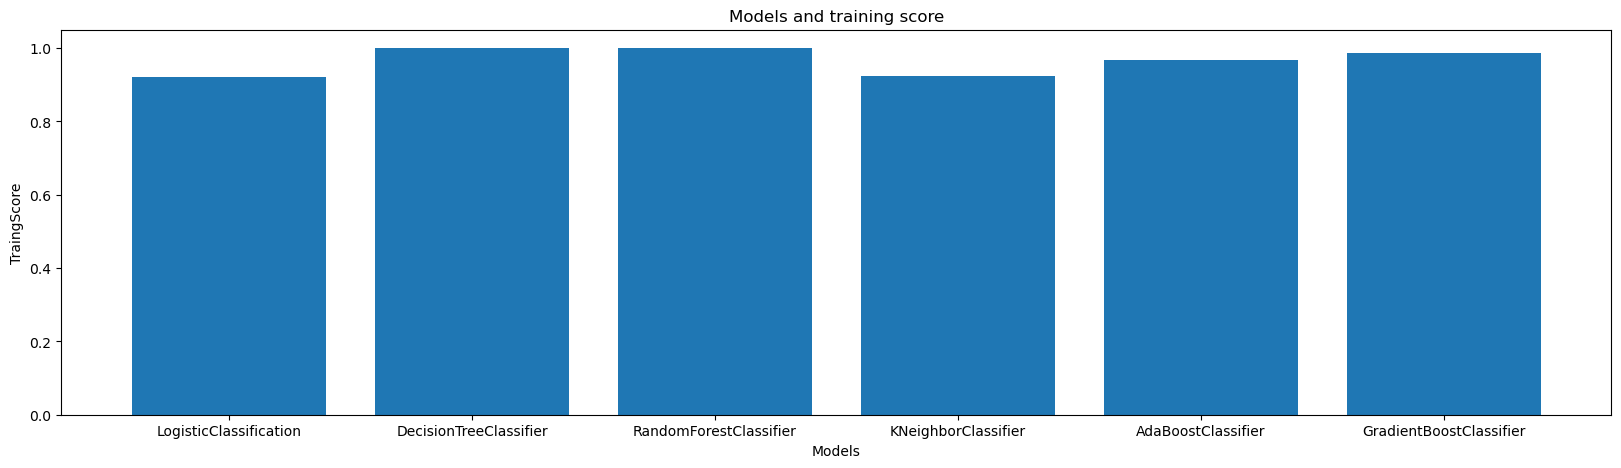

In [355]:
x=score.Model
y=score.Training_Score
plt.figure(figsize=(20,5))
plt.bar(x,y)
plt.xlabel('Models')
plt.ylabel('TraingScore')
plt.title("Models and training score")
plt.show()

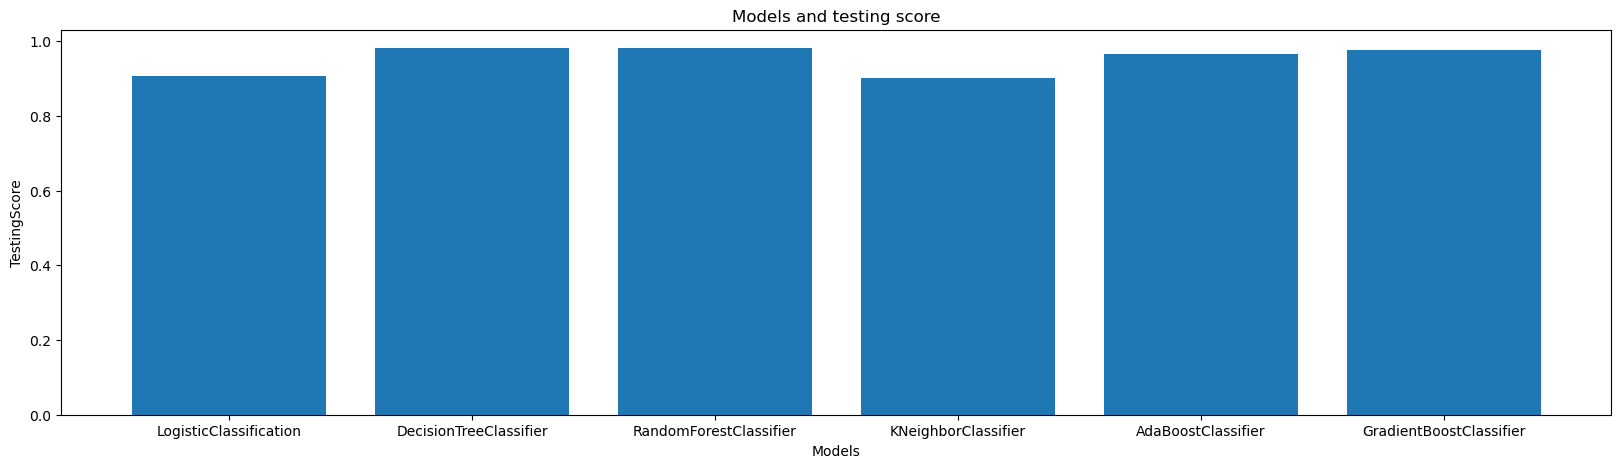

In [356]:
x=score.Model
y=score.Test_Score
plt.figure(figsize=(20,5))
plt.bar(x,y)
plt.xlabel('Models')
plt.ylabel('TestingScore')
plt.title("Models and testing score")
plt.show()

In [357]:
with open('model.pkl', 'wb') as file:
    pickle.dump(model2, file)


with open('model.pkl', 'rb') as file:
    loaded_model = pickle.load(file)
    
print(loaded_model.predict(xtest))

[' Rejected' ' Approved' ' Rejected' ... ' Approved' ' Rejected'
 ' Rejected']


In [359]:
no_of_dependents = int(input('Enter No of Dependents: '))
education = int(input('Enter Education (0/1): '))
self_employed = int(input('Enter Self Employed (0/1): '))
income_annum = float(input('Enter Annual Income: '))
loan_amount = float(input('Enter Loan Amount: '))
loan_term = int(input('Enter Loan Term: '))
cibil_score = int(input('Enter CIBIL Score: '))
residential_assets_value = float(input('Enter Residential Assets Value: '))
commercial_assets_value = float(input('Enter Commercial Assets Value: '))
luxury_assets_value = float(input('Enter Luxury Assets Value: '))
bank_asset_value = float(input('Enter Bank Asset Value: '))
input_data = [[no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,
    luxury_assets_value,bank_asset_value]]
input_scaled = scaler.transform(input_data)
prediction = loaded_model.predict(input_scaled)
print(prediction)

Enter No of Dependents:  0
Enter Education (0/1):  1
Enter Self Employed (0/1):  0
Enter Annual Income:  1024065
Enter Loan Amount:  500000
Enter Loan Term:  54
Enter CIBIL Score:  41
Enter Residential Assets Value:  52000000
Enter Commercial Assets Value:  1400000
Enter Luxury Assets Value:  0
Enter Bank Asset Value:  5000400


[' Rejected']


In [377]:
x = data.drop('loan_status', axis=1)
y = data['loan_status']

scores = cross_val_score(model3, x, y, cv=5)
print(scores.mean())

0.9819636439512287
